# Maximum Initial Mass

This notebook is a hands-on tutorial to reproduce the homotopy results of the paper *The Maximum Initial Mass* ({cite:p}`mim`). In that work, the optimal-control formulation of **maximum-initial-mass (MIM)** is introduced and analyzed, opening practical applications in homotopy methods, reachability analysis, and low-thrust optimization.

For fixed transfer time and fixed final state, the **maximum-initial-mass (MIM)** problem asks for the largest admissible initial mass that still allows a feasible low-thrust transfer. In Pontryagin form, this leads to the same thrust-direction law as the minimum-time problem and, in the nondegenerate case, to full throttle along the trajectory.

A practical consequence for continuation is that, instead of continuing in thrust, one can work on the smooth surface
$$
\mathcal{M}:(t_f, N_{\mathrm{rev}}) \mapsto m_0^*(t_f, N_{\mathrm{rev}}),
$$
and track iso-$\mathcal{M}$ curves to recover multi-revolution minimum-time branches.

In this notebook we formulate the TPBVP with the `pykep` time-optimal machinery, then modify the shooting function to fix $t_f$ and solve for $m_0$, finally constructing and exploring the homotopy path on the MIM surface.

## 1) TPBVP Setup in pykep

The MIM TPBVP can be implemented with the same augmented dynamics used for time-optimal low-thrust transfers.

The key changes are in the boundary conditions and shooting residuals, not in the dynamics:

- We fix transfer time $t_f$ (or optionally keep it free in the early continuation stage).
- We free the initial mass $m_0$ and solve for the largest feasible one.
- We enforce terminal constraints on the orbital state together with $\lambda_m(t_f)=0$.
- Depending on the stage, we either fix terminal longitude $L_f$ or leave it free through the associated transversality residual.

In this section we import the required libraries and build the numerical objects used throughout the notebook.

In [1]:
import pykep as pk
import numpy as np
import heyoka as hy
import pygmo as pg
import pygmo_plugins_nonfree as ppnf

from scipy.optimize import root
from time import time
from copy import deepcopy
import pickle as pkl

from matplotlib import pyplot as plt

## 2) Dynamics, Costates, and Shooting Functions

This preamble defines:

- The augmented dynamics in modified equinoctial elements.
- A variational integrator to obtain analytical Jacobians for shooting.
- Utility callable functions for Hamiltonian, switching function, throttle, and thrust direction.
- The residual and Jacobian functions for the MIM shooting method.

Mathematically, we solve a root-finding problem of the form

$$
F(z)=0,
$$

where $z$ contains the free initial mass and initial costates (plus optional free-final-time variable), and $F$ collects terminal-constraint mismatches.

When `free_time=True`, this notebook appends one additional scalar Hamiltonian-based condition (`H_0=0`) to close the numerical system during continuation. (this is to be considered as a gauge condition or a necessary condition accordingly)

In [2]:
# The raw augmented dynamics
dyn = pk.ta.peq_dyn(pk.optimality_type.TIME)
# Its variational form (only needed entries)
m, lp, lf, lg, lh, lk, lL, lm = hy.make_vars('m', 'lp', 'lf', 'lg', 'lh', 'lk', 'lL', 'lm')
dyn_var_mim = hy.var_ode_sys(dyn, [m, lp, lf, lg, lh, lk, lL, lm], order=1)
# The Taylor integrator
ta = hy.taylor_adaptive(dyn, tol=1e-16, compact_mode=True)
# The Variational Taylor integrator (8 digits generally enough)
ta_var_mim = hy.taylor_adaptive(dyn_var_mim, tol=1e-6, compact_mode=True)
ic_var_mim = ta_var_mim.state[14:].copy()
# The Hamiltonian
H_func = pk.ta.get_peq_H_cfunc(pk.optimality_type.TIME)
# The switching function (always negative, not useful for this time optimal case, but still)
SF_func = pk.ta.get_peq_SF_cfunc(pk.optimality_type.TIME)
# The magnitude of the throttle (always 1, but still)
u_func = pk.ta.get_peq_u_cfunc(pk.optimality_type.TIME)
# The thrust direction
i_vers_func = pk.ta.get_peq_i_vers_cfunc(pk.optimality_type.TIME)
# The dynamics cfunc
vars_s = hy.make_vars('p', 'f', 'g', 'h', 'k', 'L', 'm', 'lp', 'lf', 'lg', 'lh', 'lk', 'lL', 'lm')
dyn_func = hy.cfunc([it[1] for it in ta.sys], vars = vars_s)
# Hamiltonian's derivatives
dH_symfunc = hy.diff_tensors(func = H_func.fn, diff_args = [m, lp, lf, lg, lh, lk, lL, lm], diff_order = 1).gradient
dH_func = hy.cfunc(dH_symfunc, vars = H_func.vars)

In [3]:
def shooting_mim(x, mee0, meef, tf, normalize_lambdas=True, free_Lf=True, free_time=True, data=False):
    # Decision vector:
    #   free_time=True  -> [m0, lp0, lf0, lg0, lh0, lk0, lL0, (l0), tf]
    #   free_time=False -> [m0, lp0, lf0, lg0, lh0, lk0, lL0, (l0)]
    # Return value:
    #   In general -> [p(tf)-pf, f(tf)-ff, g(tf)-gf, h(tf)-hf, k(tf)-kf, L_condition, lm(tf)-lmf, (H0), (normalization)]
    #   free_Lf=True    -> L_condition = lLf
    #   free_Lf=False   -> L_condition = L(tf)-Lf
    #   free_time=True  -> H0 = H(initial_conditions) should be zero
    #   normalize_lambdas=True -> normalization = l0^2 + lp0^2 + lf0^2 + lg0^2 + lh0^2 + lk0^2 + lL0^2 + l0^2 - 1
    n_expected = 7 + int(normalize_lambdas) + int(free_time)
    if len(x) != n_expected:
        raise ValueError(f"shooting_mim expected len(x)={n_expected}, got {len(x)}")
    tf_eval = x[-1] if free_time else tf
    
    lambda0 = x[7] if normalize_lambdas else 1.0
    initial_conditions = [*mee0, *x[0:7], lambda0]

    ta.time = 0.0
    ta.state[:14] = initial_conditions

    if data:
        return ta.propagate_grid(np.linspace(0, tf_eval, data))
    
    ta.propagate_until(tf_eval)

    pf, ff, gf, hf, kf, Lf, mf = ta.state[:7]
    lpf, lff, lgf, lhf, lkf, lLf, lmf = ta.state[7:14]

    L_condition = lLf if free_Lf else Lf - meef[5]

    retval = [
        pf - meef[0],
        ff,
        gf,
        hf,
        kf,
        L_condition, # (L free or L fixed)
        lmf  # mf free
    ]

    if free_time:
        H0 = H_func(initial_conditions, pars=list(ta.pars)+[0.,0.])[0]  # Hamiltonian should be zero (free time (not min time))
        retval.append(H0)  # free time
        
    if normalize_lambdas:
        retval.append(x[1] * x[1] + x[2] * x[2] + x[3] * x[3] + x[4] * x[4] + x[5] * x[5] + x[6] * x[6] + 2 * x[7] * x[7] - 1)        
    return retval

In [4]:
def shooting_mim_grad(x, mee0, meef, tf, normalize_lambdas=True, free_Lf=True, free_time=True):
    # Decision vector (dv):
    #   free_time=True  -> [m0, lp0, lf0, lg0, lh0, lk0, lL0, (l0), tf]
    #   free_time=False -> [m0, lp0, lf0, lg0, lh0, lk0, lL0, (l0)]
    # Return value of shooting_mim (f):
    #   In general -> [p(tf)-pf, f(tf)-ff, g(tf)-gf, h(tf)-hf, k(tf)-kf, L_condition, lm(tf)-lmf, (H0), (normalization)]
    #   free_Lf=True    -> L_condition = lLf
    #   free_Lf=False   -> L_condition = L(tf)-Lf
    #   free_time=True  -> H0 = H(initial_conditions) should be zero
    #   normalize_lambdas=True -> normalization = l0^2 + lp0^2 + lf0^2 + lg0^2 + lh0^2 + lk0^2 + lL0^2 + l0^2 - 1
    #
    # We seek to compute df/dv
    
    n_expected = 7 + int(normalize_lambdas) + int(free_time)
    if len(x) != n_expected:
        raise ValueError(f"shooting_mim expected len(x)={n_expected}, got {len(x)}")
    tf_eval = x[-1] if free_time else tf
    
    lambda0 = x[7] if normalize_lambdas else 1.0
    initial_conditions = [*mee0, *x[0:7], lambda0]

    ta_var_mim.time = 0.0
    ta_var_mim.state[:14] = initial_conditions
    ta_var_mim.state[14:] = ic_var_mim
    ta_var_mim.propagate_until(tf_eval)

    st = ta_var_mim.state

    def sens(component):
        sl = ta_var_mim.get_vslice(order=1, component=component)
        result = np.array(st[sl])[:7]  # sensitivities w.r.t. [m0, lp0, ..., lL0]
        
        if normalize_lambdas:
            result = np.concatenate([result, [np.array(st[sl])[7]]])  # add d/dl0
        
        if free_time:
            dcomp_dtf = dyn_func(st[:14], pars=ta_var_mim.pars)[component]
            result = np.concatenate([result, [dcomp_dtf]])  # add d/dtf
    
        return result

    rows = []

    # Residuals p, f, g, h, k, L, lm
    L_residual = 12 if free_Lf else 5
    for i in [0, 1, 2, 3, 4, L_residual, 13]:
        rows.append(sens(i))

    # Residual H0 (if free time)
    if free_time:
        dHdx = np.array(dH_func(initial_conditions, pars=ta.pars), dtype=float)
        # dHdx has derivatives [dH/dm, dH/dlp, ..., dH/dlL, dH/dl0]
        
        if normalize_lambdas:
            # Decision vector: [m, lp, lf, lg, lh, lk, lL, l0, tf]
            # We need:     [dH/dm, dH/dlp, ..., dH/dlL, dH/dl0, dH/dtf]
            h0_row = np.concatenate([dHdx[:8], [0.]])  # 8 derivatives + 1 for tf
        else:
            # Decision vector: [m, lp, lf, lg, lh, lk, lL, tf]
            # We need:     [dH/dm, dH/dlp, ..., dH/dlL, dH/dtf]
            h0_row = np.concatenate([dHdx[:7], [0.]])  # 7 derivatives + 1 for tf
        
        rows.append(h0_row)

    # Residual normalization (if normalize_lambdas)
    if normalize_lambdas:
        norm_grad = np.array([0., 2*x[1], 2*x[2], 2*x[3], 2*x[4], 2*x[5], 2*x[6], 4*x[7]])
        if free_time:
            norm_grad = np.concatenate([norm_grad, [0.]])
        rows.append(norm_grad)

    return np.array(rows).reshape(n_expected, n_expected)
    

### 2.1) Sanity Check: Analytical vs Numerical Jacobian

Before running large continuation loops, we verify the Jacobian in `shooting_mim_grad` against finite differences.

A small maximum error indicates that the analytical Jacobian is implemented consistently and is suitable for robust Newton/hybrid solves.

In [5]:
mee0 = [1.0, 0.0, 0.0, 0.0, 0.0, 1.0]
meef = [1.0, 0.0, 0.0, 0.0, 0.0, 1.0]
ta.pars[:] = [1.0, 0.0003, 1.]
ta_var_mim.pars[:] = [1.0, 0.0003, 1.]
for normalize_lambdas in [False, True]:
    for free_Lf in [False, True]:
        for free_time in [False, True]:
            x0 = [-0.3]*(7+normalize_lambdas+free_time)
            num = pg.estimate_gradient_h(lambda x: shooting_mim(x, mee0, meef, tf=4.3535, normalize_lambdas=normalize_lambdas, free_Lf = free_Lf, free_time = free_time), x0, dx=1e-8)
            an = shooting_mim_grad(x0, mee0, meef, tf=4.3535, normalize_lambdas=normalize_lambdas, free_Lf = free_Lf, free_time = free_time).reshape(-1,)
            error = num-an
            error_max = np.max(np.abs(error))
            print(f"normalize_lambdas={str(normalize_lambdas):<5} | free_Lf={str(free_Lf):<5} | free_time={str(free_time):<5} | max error={error_max:10.3e}"
)

normalize_lambdas=False | free_Lf=False | free_time=False | max error= 1.452e-07
normalize_lambdas=False | free_Lf=False | free_time=True  | max error= 1.381e-08
normalize_lambdas=False | free_Lf=True  | free_time=False | max error= 5.884e-08
normalize_lambdas=False | free_Lf=True  | free_time=True  | max error= 1.381e-08
normalize_lambdas=True  | free_Lf=False | free_time=False | max error= 1.452e-07
normalize_lambdas=True  | free_Lf=False | free_time=True  | max error= 1.102e-08
normalize_lambdas=True  | free_Lf=True  | free_time=False | max error= 5.884e-08
normalize_lambdas=True  | free_Lf=True  | free_time=True  | max error= 8.828e-09


## 3) Benchmark Problem Definition (GTO to GEO)

We reproduce the benchmark transfer discussed in the paper: a low-thrust multi-revolution GTO-to-GEO rendezvous.

This cell sets:

- Nondimensional units and scaling factors.
- Initial and target orbits.
- Propulsion parameters ($T_{\max}$, $v_{eff}$).
- Initial/final MEE states used in shooting.

These constants define the physical scenario for all continuation stages below.

In [6]:
# units
L = 6378137
MU = 398600441800000.0
V = np.sqrt(MU / L)
TIME = L / V
ACC = V / TIME
MASS = 1500.
FORCE = MASS * ACC

# Problem setting
gto_param = [26571430, 0.75, 7. * pk.DEG2RAD, 0, 0, np.pi]
geo_param = [42165000, 0, 0, 0, 0, 0]
# Used for visualization later on
gto = pk.planet(pk.udpla.keplerian(elem=gto_param, when=pk.epoch(0.), mu_central_body=pk.MU_EARTH))
geo = pk.planet(pk.udpla.keplerian(elem=geo_param, when=pk.epoch(0.), mu_central_body=pk.MU_EARTH))
t0_days = 0
tf_days = 0.55 # days
tof_days = tf_days - t0_days
tof = (tof_days) * pk.DAY2SEC / TIME
r0, v0 = gto.eph(t0_days)
r0 = [it / L for it in r0]
v0 = [it / V for it in v0]
mee0 = pk.ic2mee([r0, v0], 1.)
rf, vf = geo.eph(t0_days + tof_days)
rf = [it / L for it in rf]
vf = [it / V for it in vf]
meef = pk.ic2mee([rf, vf], 1.)
T_max = 3.0 / FORCE
veff = 1994.75 * pk.G0 / V

ta.pars[0] = 1.0  # mu
ta.pars[1] = T_max  # max thrust
ta.pars[2] = veff  # veff

ta_var_mim.pars[0] = 1.0  # mu
ta_var_mim.pars[1] = T_max  # max thrust
ta_var_mim.pars[2] = veff  # veff

tf = 10.

## 4) Seed Solution for Continuation

We first compute a feasible seed extremal with free final time and fixed terminal longitude.

This seed plays the same role as a low-complexity initialization in classical homotopy: it provides a numerically stable starting point from which we can continue toward higher-revolution, higher-mass solutions.

In [7]:
normalize_lambdas = False
free_Lf = False
meef[5] = 10.
free_time = True
n = 7 + int(normalize_lambdas) + int(free_time)

In [8]:
n_trials = 40
time_start = time()
for i in range(n_trials):
    x0 = np.random.rand(n) - 0.5 # initial guess for [m0, lambdas, lambda_0]
    x0[0] = np.random.rand()   # m0 should be positive
    x0[-1] = np.random.rand() * 100 + 50

    res = root(lambda x: shooting_mim(x, mee0, meef, tf, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time), x0, method="hybr", tol=1e-8, options = {"factor": 1., "diag": [1]*(n)}, jac=lambda x: shooting_mim_grad(x, mee0, meef, tf, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time))  # factor=1 is very important for convergence
    if np.linalg.norm(res["fun"]) < 1e-8 and res.x[0]>0:
        print(".", end="")
        sol = res.x.copy()
        break
    else:
        print("x", end="")
time_end = time()
initial = [sol, mee0, meef, sol[-1]]
print(f"\nMim: {initial[0][0]*MASS:.2f} kg")
print(f"Tof: {tf*TIME*pk.SEC2DAY*24:.2f} hours")
print(f"Nrev: {ta.state[5]/(2*np.pi):.2f}")
print(f"Decision vector: {initial[0]}")

.
Mim: 88.61 kg
Tof: 2.24 hours
Nrev: 1.59
Decision vector: [  5.90761528e-02  -4.44999443e-02  -1.86853221e-01  -5.72598813e-02
   3.34701940e-02   8.48157549e-05   5.63154164e-02   7.43498018e+01]


### 4.1) Visual Check of the Seed Trajectory

We plot the seed transfer in Cartesian space to ensure that the numerically converged extremal is physically consistent before launching continuation.

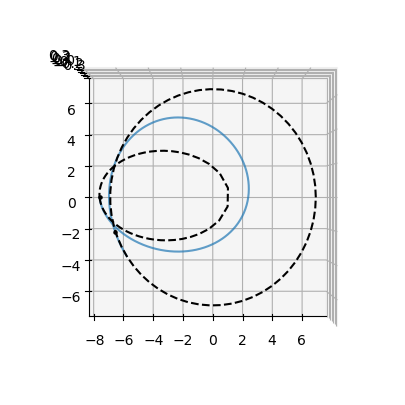

In [9]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Getting the data
sol_initial = shooting_mim(*initial, data=1000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)[-1]
r=[]
for item in sol_initial:
    r.append(pk.mee2ic(item[:6], 1.0)[0])
r = np.array(r)
# create 3D figure
plt.figure(figsize=(10,5))
ax = plt.subplot(111, projection='3d')
ax.plot(r[:,0], r[:,1], r[:,2], alpha=0.7)
pk.plot.add_planet(ax, gto, t0_days, c='k', s=5, units=L)
pk.plot.add_planet_orbit(ax, gto, c='k', ls='--', units=L)
pk.plot.add_planet(ax, geo, t0_days+tof_days, c='k', s=5, units=L)
pk.plot.add_planet_orbit(ax, geo, c='k', ls='--', units=L)

ax.view_init(elev=90, azim=-90)



## 5) Continuation in Terminal Longitude with Free Time

Starting from the seed, we increase terminal longitude $L_f$ while keeping final time free inside the shooting solve.

This traces a smooth continuation path and increases the maximum admissible initial mass until we reach the target mass level (1500 kg in this benchmark).

In the paper notation, this corresponds to moving along the MIM manifold while allowing the solver to adapt $t_f$. This stage is used here as a practical homotopy mechanism to reach the 1500 kg level set robustly.

In [10]:
current, _, meef_current, tf_current = deepcopy(initial)
mim_history = []
tof_history = []
L_history = []

normalize_lambdas = False
free_Lf = False
free_time = True
n = 7 + int(normalize_lambdas) + int(free_time)

In [11]:
increment = 5
target_mass = 1500
for i in range(300):
    meef_current[5]+=increment
    res = root(lambda x: shooting_mim(x, mee0, meef_current, tf_current, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time), current, method="hybr", tol=1e-8, options = {"factor": 1., "diag": [1]*(n)}, jac=lambda x: shooting_mim_grad(x, mee0, meef_current, tf_current, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time))  # factor=1 is very important for convergence
    if res.success:
        print(f".", end="")
        mass = res.x[0]*MASS
        if (np.abs(mass-target_mass)) < 0.001:
            break
        if mass > target_mass:
            meef_current[5]-=increment
            increment *= 0.5
            continue
        current = res.x
        mim_history.append(mass)
        tof_history.append(res.x[-1]*TIME*pk.SEC2DAY*24) 
        L_history.append(meef_current[5]/(2*np.pi))
    else:
        print(f"x", end="")

print(f"\nMim: {mass:.2f} kg")
print(f"Tof: {current[-1]*TIME*pk.SEC2DAY*24:.2f} hours")
print(f"Nrev: {meef_current[5]/(2*np.pi):.2f}")
homotopy1 = [current, mee0, meef_current, current[-1]]

.......................................
Mim: 1500.00 kg
Tof: 308.34 hours
Nrev: 14.85


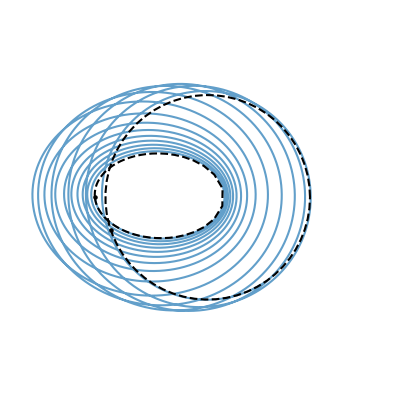

In [12]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Getting the data
sol_initial = shooting_mim(*homotopy1, data=10000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)[-1]
r=[]
for item in sol_initial:
    r.append(pk.mee2ic(item[:6], 1.0)[0])
r = np.array(r)
# create 3D figure
plt.figure(figsize=(5,5))
ax = plt.subplot(111, projection='3d')
ax.plot(r[:,0], r[:,1], r[:,2], alpha=0.7)
pk.plot.add_planet(ax, gto, t0_days, c='k', s=5, units=L)
pk.plot.add_planet_orbit(ax, gto, c='k', ls='--', units=L)
pk.plot.add_planet(ax, geo, t0_days+tof_days, c='k', s=5, units=L)
pk.plot.add_planet_orbit(ax, geo, c='k', ls='--', units=L)

ax.view_init(elev=90, azim=-90)

D=8
ax.set_xlim([-D, D])
ax.set_ylim([-D, D])

# switching off the grid and axis
ax.axis('off');

### 5.1) Mass Evolution Along Continuation

This diagnostic plot reports how recovered MIM changes with the terminal-revolution proxy $L_f/(2\pi)$.
A smooth trend is a useful indicator that continuation is following a consistent branch.

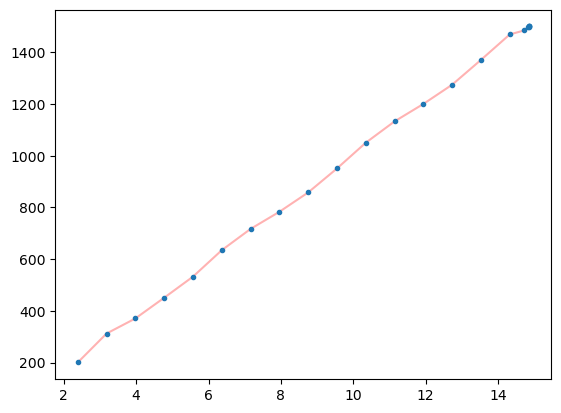

In [13]:
plt.plot(L_history, mim_history, 'r-', alpha=0.3)
plt.plot(L_history, mim_history, '.')

## 6) Building the $\mathcal{M}(t_f, N_{\mathrm{rev}})$ Surface

After reaching the target-mass branch, we switch to fixed-time solves and sweep a grid in $(t_f, L_f)$.

Each successful solve gives one point on the MIM surface, i.e. the maximal feasible initial mass for that pair of parameters. The resulting grid is then used to visualize iso-mass contours and recover candidate minimum-time branches.

Important interpretation note: points on the 1500 kg iso-$\mathcal{M}$ curve are fixed-mass extremals; local minima of $t_f$ along that curve are minimum-time candidates.

In [14]:
current, _, meef_current, tf_current = deepcopy(homotopy1)

normalize_lambdas = False
free_Lf = False
free_time = False
n = 7 + int(normalize_lambdas) + int(free_time)

current = current[:-1]

mass = current[0]*MASS
tof = tf_current
Lf = meef_current[5]
print(f"Mim: {mass:.2f} kg, Tof: {tof:.2f} nd, Lf: {Lf:.2f}")

Mim: 1500.00 kg, Tof: 1375.80 nd, Lf: 93.29


### 6.0) Two-Parameter Continuation on a Grid

We define the $(L_f, t_f)$ grid where the MIM surface is sampled, then allocate arrays for solved masses and decision vectors.

We use row-wise continuation over $t_f$, and within each row continue over $L_f$ using the previous solution as seed.

Running the full sweep can take a long time because it solves $100\times100$ TPBVPs. The code below is intentionally guarded by a flag; by default we rely on the precomputed dataset loaded in the next section.

In [29]:
Lf_grid = np.linspace(Lf, 1.3*Lf, 100)
tf_grid = np.linspace(tof, tof/1.1, 100)

mim = np.zeros((len(tf_grid), len(Lf_grid)))
sols = np.zeros((len(tf_grid), len(Lf_grid)), dtype=object)

In [30]:
#current_row_seed = deepcopy(current)
#for i, tf in enumerate(tf_grid):
#    current = deepcopy(current_row_seed)
#    print("\n Row", i, ": ", np.linalg.norm(current), end="")
#    for j, Lf in enumerate(Lf_grid):
#        meef_current[5] = Lf
#        res = root(lambda x: shooting_mim(x, mee0, meef_current, tf, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time), current, method="hybr", tol=1e-8, options = {"factor": 1., "diag": [1]*(n)}, jac=lambda x: shooting_mim_grad(x, mee0, meef_current, tf, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time))  # factor=1 is very important for convergence
#        if res.success:
#            print(f".", end="")
#            current = res.x
#            mim[i][j] = current[0]*MASS
#            sols[i][j] = current
#            if j==0:
#                current_row_seed = deepcopy(current)
#        else:
#            print(f"x", end="")
#            break

If you do run the full grid cell above, it is a good idea to store the results.

In [31]:
#import pickle as pkl
#with open("data/MY_mim_surface.pkl", "wb") as f:
#    pkl.dump((Lf_grid, tf_grid, mim), f)

### 6.2) Persisting and Reloading the Surface

Surface generation is expensive. Save the computed grid once, then reload it for plotting and branch analysis.

The notebook ships with a precomputed dataset at `data/mim_surface.pkl`, so the tutorial remains runnable in a reasonable time.

In [18]:
Lf_grid, tf_grid, mim = pkl.load(open("data/mim_surface.pkl", "rb"))

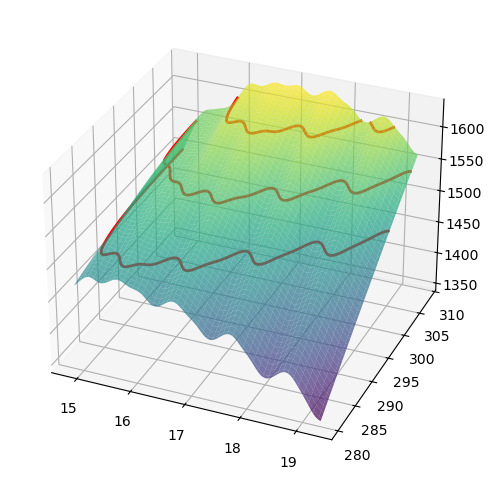

In [19]:
# Visualize the mim surface Lf_grid, tf_grid, mim
plt.figure(figsize=(6,7))
ax = plt.subplot(111, projection='3d')

X, Y = np.meshgrid(Lf_grid, tf_grid)   # both (2, 100)
X = X/(2*np.pi)
Y = Y*TIME*pk.SEC2DAY*24
ax.plot_surface(X, Y, mim, cmap='viridis', alpha=0.7)
ax.contour(X, Y, mim, levels=[1500], colors='r', linewidths=2)
ax.contour(X, Y, mim, levels=[1550], colors='r', linewidths=2)
ax.contour(X, Y, mim, levels=[1600], colors='r', linewidths=2)


ax.view_init(elev=30, azim=-67)

### 6.3) Surface Visualization

We first inspect the 3D surface $m_0^*(t_f, N_{\mathrm{rev}})$, then the 2D contour map.

The 1500 kg iso-$\mathcal{M}$ contour is the key object: extrema of $t_f$ along this curve correspond to candidate minimum-time branches in the fixed-initial-mass viewpoint.

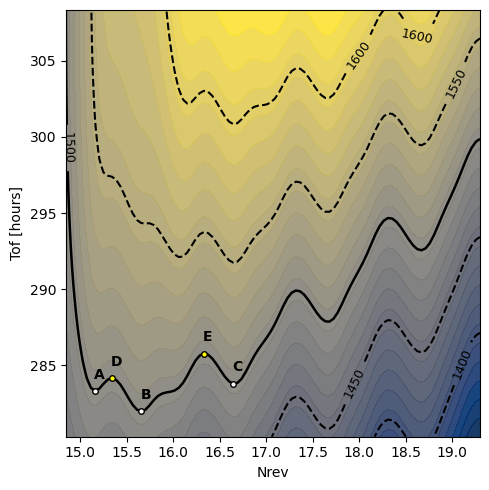

In [20]:
# Visualize mim with colored map + contour lines
plt.figure(figsize=(5,5))
ax = plt.subplot(111)

# Filled color map
fill_levels = np.linspace(np.nanmin(mim), np.nanmax(mim), 30)
cf = ax.contourf(X, Y, mim, levels=fill_levels, cmap="cividis", alpha=0.9)

# Contour lines: dashed for all except 1500
other_levels = [1400, 1450, 1550, 1600]
cs_other = ax.contour(
    X, Y, mim,
    levels=other_levels,
    colors="k",
    linestyles="--",
    linewidths=1.5
)

# 1500 contour as the only solid line
cs_1500 = ax.contour(
    X, Y, mim,
    levels=[1500],
    colors="k",
    linestyles="-",
    linewidths=1.8
)

# Labels
ax.clabel(cs_other, cs_other.levels, inline=True, fmt="%.0f", fontsize=9)
ax.clabel(cs_1500, cs_1500.levels, inline=True, fmt="%.0f", fontsize=9)

# --- User-editable annotation specification ---
# Set target points on the 1500 contour by x coordinate (Nrev) and label.
# If two labels share the same x_target, points are chosen as distinct points on the contour.
point_specs = [
    {"label": "A", "x_target": 15.15},
    {"label": "B", "x_target": 15.65},
    {"label": "C", "x_target": 16.65},
    {"label": "D", "x_target": 15.35},
    {"label": "E", "x_target": 16.32},
]

# Optional per-label text offsets for readability
text_offsets = {
    "A": (-0.01, 0.8),
    "B": (-0.01, 0.8),
    "C": (-0.01, 0.8),
    "D": (-0.01, 0.8),
    "E": (-0.01, 0.8),
}

# Point color configuration
default_point_color = "white"
highlight_point_color = "yellow"
highlight_labels = {"D", "E"}

# Extract vertices of the 1500 contour in a Matplotlib-version-safe way
segs_1500 = cs_1500.allsegs[0]
verts_1500 = [seg for seg in segs_1500 if seg.shape[0] > 0]

if len(verts_1500) == 0:
    raise RuntimeError("No 1500 contour segment found in current plotting range")

pts_1500 = np.vstack(verts_1500)

# Keep already-used points apart to avoid stacking markers when x_target repeats
used_points = []
min_dist = 0.15

for spec in point_specs:
    label = spec["label"]
    x_target = spec["x_target"]

    order = np.argsort(np.abs(pts_1500[:, 0] - x_target))
    chosen = None
    for idx in order:
        cand = pts_1500[idx]
        if all(np.linalg.norm(cand - up) > min_dist for up in used_points):
            chosen = cand
            break

    # Fallback in case all candidates are too close
    if chosen is None:
        chosen = pts_1500[order[0]]

    used_points.append(chosen)
    xv, yv = chosen

    point_color = highlight_point_color if label in highlight_labels else default_point_color
    ax.plot(xv, yv, marker="o", color=point_color, markeredgecolor="k", markersize=4, zorder=5)
    dx, dy = text_offsets.get(label, (0.03, 0.2))
    ax.text(xv + dx, yv + dy, label, fontsize=10, fontweight="bold", color="k")

ax.set_xlabel("Nrev")
ax.set_ylabel("Tof [hours]")
plt.tight_layout()

## 7) Trajectory Datasets for Labeled Branches

The following cells define decision vectors for A/B/C/D/E and evaluate dense trajectory histories for plotting.

This mirrors the paper-style branch comparison on a common MIM level set.

In [21]:
x_A = np.array([ 1.00000268, -0.39203057, -1.32360439, -0.01497821,  0.42668529, -0.01022831,  0.01188412])
meef_current[5] = Lf_grid[7]
tf = tf_grid[89]+0.82
data_A = shooting_mim(x_A, mee0, meef_current, tf, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [22]:
x_B = np.array([ 0.99999759, -0.33491311, -0.91152179, -0.01065958,  0.44993837, -0.01011572,  0.00863597])
meef_current[5] = Lf_grid[18]
tf = tf_grid[93]-0.16
data_B = shooting_mim(x_B, mee0, meef_current, tf, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [23]:
x_C = np.array([ 1.00000014, -0.20400227, -0.04617363,  0.00517522,  0.46687152,-0.00935368, -0.00244366])
meef_current[5] = Lf_grid[40]
tf = tf_grid[87]+0.39
data_C = shooting_mim(x_C, mee0, meef_current, tf, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [24]:
x_D = np.array([ 1.00000067, -0.3565124 , -1.08335089, -0.01131665,  0.43498536, -0.00985441,  0.00917867])
meef_current[5] = Lf_grid[11]
tf = tf_grid[85]-0.5
data_D = shooting_mim(x_D, mee0, meef_current, tf, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [25]:
x_E = np.array([ 1.00000225, -0.20970184, -0.09911761,  0.00412833,  0.45504409,-0.01026745, -0.00280334])
meef_current[5] = Lf_grid[33]
tf = tf_grid[80]+0.36
data_E = shooting_mim(x_E, mee0, meef_current, tf, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [26]:
normalize_lambdas = False
free_Lf = False
free_time = True
n = 7 + int(normalize_lambdas) + int(free_time)
data_0 = shooting_mim(*initial, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

In [27]:
data_O = shooting_mim(*homotopy1, data = 3000, normalize_lambdas = normalize_lambdas, free_Lf = free_Lf, free_time = free_time)

## 8) Final Tutorial Figure and Interpretation

This final panel reproduces the paper-style narrative view: contour map plus representative trajectories.

Read it as follows:

- The contour map organizes the solution space in \((N_{\mathrm{rev}}, t_f)\).
- The 1500 kg iso-curve is the fixed-initial-mass family.
- Labeled trajectories correspond to different extremals on that same family, including locally fast and locally slow branches.

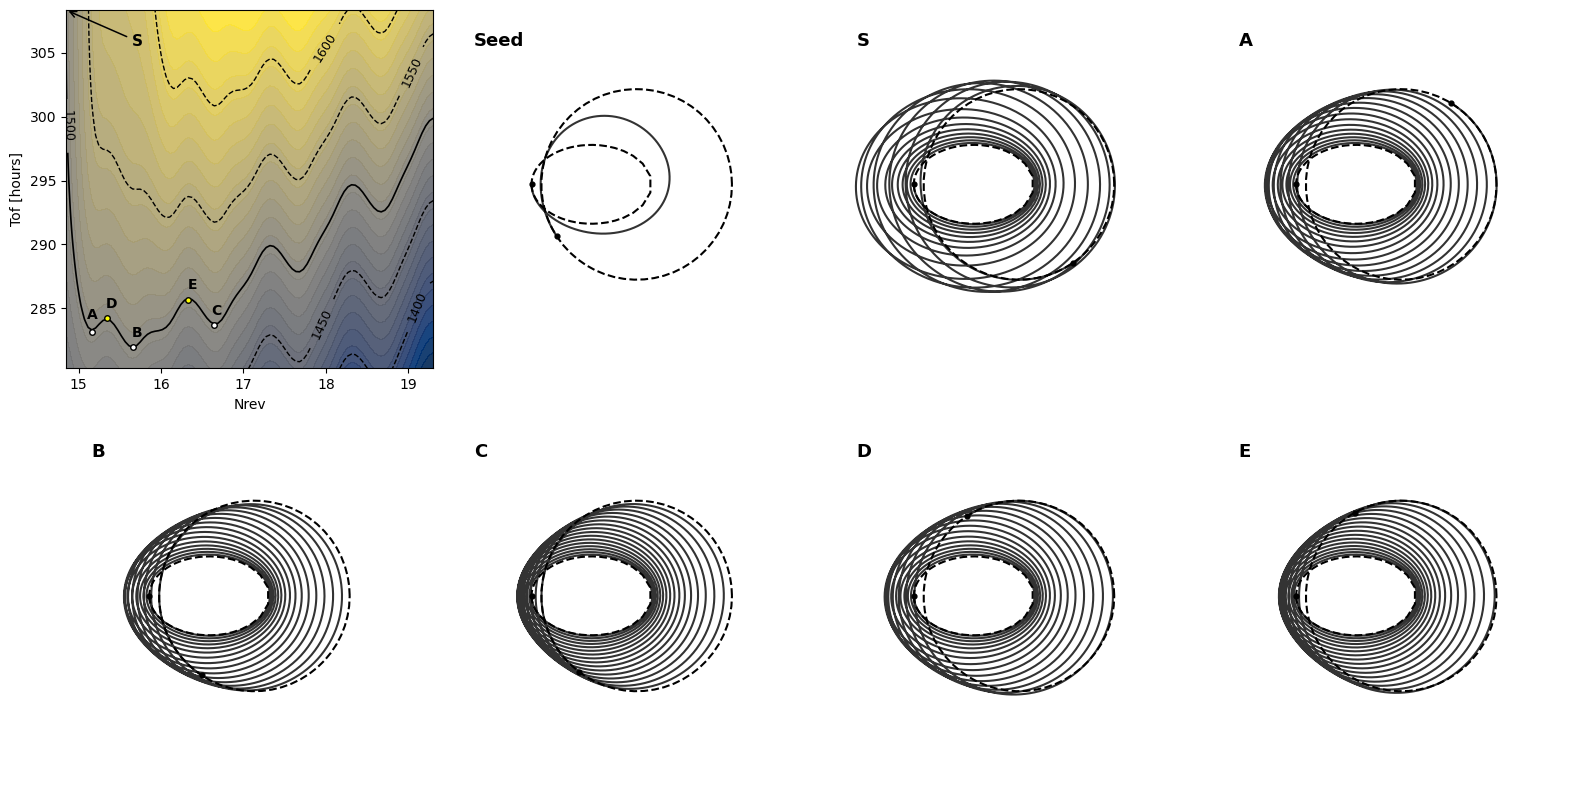

In [28]:
# Display contour map first, then data_0, data_O, data_A, data_B, data_C, data_D, data_E trajectories

# User-editable panel configuration
orbit_panels = [
    ("Seed", data_0),
    ("S", data_O),
    ("A", data_A),
    ("B", data_B),
    ("C", data_C),
    ("D", data_D),
    ("E", data_E),
]

# User-editable free text overlay positions in axes coordinates
label_positions = {
    "Seed": (0.06, 0.90),
    "S": (0.06, 0.90),
    "A": (0.06, 0.90),
    "B": (0.06, 0.90),
    "C": (0.06, 0.90),
    "D": (0.06, 0.90),
    "E": (0.06, 0.90),
}


def traj_to_r(data):
    sol = data[-1]
    return np.array([pk.mee2ic(state[:6], 1.0)[0] for state in sol])


n_orbits = len(orbit_panels)
ncols = 4
nrows = 2
fig = plt.figure(figsize=(4.0 * ncols, 4.0 * nrows))

# Build 8 slots: first one is contour (2D), next 7 are orbit panels (3D).
axes = []
for i in range(nrows * ncols):
    if i == 0:
        ax = fig.add_subplot(nrows, ncols, i + 1)
    elif i <= n_orbits:
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
    else:
        ax = fig.add_subplot(nrows, ncols, i + 1)
    axes.append(ax)

# First panel: contour map
axc = axes[0]
fill_levels = np.linspace(np.nanmin(mim), np.nanmax(mim), 30)
axc.contourf(X, Y, mim, levels=fill_levels, cmap="cividis", alpha=0.9)
cs_other_map = axc.contour(X, Y, mim, levels=[1400, 1450, 1550, 1600], colors="k", linewidths=1.0, linestyles="--")
cs_1500_map = axc.contour(X, Y, mim, levels=[1500], colors="k", linewidths=1.2, linestyles="-")
axc.clabel(cs_other_map, cs_other_map.levels, inline=True, fmt="%.0f", fontsize=9)
axc.clabel(cs_1500_map, cs_1500_map.levels, inline=True, fmt="%.0f", fontsize=9)

# Explicit letter placements on the contour subplot (same style as original index-based placement)
# Indices are (i_lf, j_tf) where:
#   i_lf indexes Lf_grid / X columns
#   j_tf indexes tf_grid / Y rows
contour_label_grid_indices = {
    "A": (7, 89),
    "B": (18, 93),
    "C": (40, 87),
    "D": (11, 85),
    "E": (33, 80),
}

# Per-letter text offsets in plot units for the contour subplot
contour_label_text_offsets = {
    "A": (-0.06, 1.0),
    "B": (-0.01, 0.8),
    "C": (-0.04, 0.8),
    "D": (-0.01, 0.8),
    "E": (-0.01, 0.8),
}

# Keep color settings consistent with the contour cell if available
default_c = default_point_color if "default_point_color" in globals() else "white"
highlight_c = highlight_point_color if "highlight_point_color" in globals() else "yellow"
highlight_set = highlight_labels if "highlight_labels" in globals() else set()

for lbl, (i_lf, j_tf) in contour_label_grid_indices.items():
    xv = X[j_tf, i_lf]
    yv = Y[j_tf, i_lf]

    point_c = highlight_c if lbl in highlight_set else default_c
    axc.plot(xv, yv, marker="o", color=point_c, markeredgecolor="k", markersize=4, zorder=5)

    dx, dy = contour_label_text_offsets.get(lbl, (0.03, 0.2))
    axc.text(xv + dx, yv + dy, lbl, fontsize=10, fontweight="bold", color="k")

# User-editable S annotation for the top-left contour corner
s_arrow_target_xy = (np.nanmin(X), np.nanmax(Y))
s_text_xy_axes_fraction = (0.18, 0.90)
axc.annotate(
    "S",
    xy=s_arrow_target_xy,
    xycoords="data",
    xytext=s_text_xy_axes_fraction,
    textcoords="axes fraction",
    fontsize=11,
    fontweight="bold",
    color="k",
    arrowprops=dict(arrowstyle="->", color="k", lw=1.1),
)

axc.set_xlabel("Nrev")
axc.set_ylabel("Tof [hours]")
axc.set_aspect("auto")

# Orbit panels (same order as orbit_panels)
D = 8
for ax, (label, data) in zip(axes[1:1 + n_orbits], orbit_panels):
    r = traj_to_r(data)

    ax.plot(r[:, 0], r[:, 1], r[:, 2], color="k", alpha=0.8)
    pk.plot.add_planet(ax, gto, t0_days, c="k", s=12, units=L)
    pk.plot.add_planet_orbit(ax, gto, c="k", ls="--", units=L)
    ax.scatter3D(r[-1, 0], r[-1, 1], r[-1, 2], c="k", s=12)
    pk.plot.add_planet_orbit(ax, geo, c="k", ls="--", units=L)

    ax.view_init(elev=90, azim=-90)
    ax.set_xlim([-D, D])
    ax.set_ylim([-D, D])
    ax.set_zlim([-D, D])
    ax.axis("off")

    # Free-position overlay text in each panel (not a title)
    tx, ty = label_positions.get(label, (0.06, 0.90))
    ax.text2D(tx, ty, label, transform=ax.transAxes, fontsize=13, fontweight="bold")

# Hide any remaining unused slots
for ax in axes[1 + n_orbits:]:
    ax.set_visible(False)

plt.tight_layout()

## 9) Wrap-Up

This notebook demonstrated the homotopy workflow around the maximum-initial-mass formulation:

- Build the MIM shooting TPBVP.
- Continue from a seed to the target-mass branch.
- Sample and visualize the smooth $\mathcal{M}(t_f, N_{\mathrm{rev}})$ surface.
- Extract representative extremal trajectories on an iso-mass contour.

As in the paper, this viewpoint provides a practical route to explore multi-revolution minimum-time structure through MIM continuation.

For reproducibility and rigor, interpret numerical values as solver-dependent (initial guess, tolerances, and continuation step sizes can shift branch labels slightly), while the qualitative geometry of the surface and iso-$\mathcal{M}$ branches should remain consistent.